<a href="https://colab.research.google.com/github/iportilla/neoj4-talk/blob/main/python_neo4j_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook accompanies this (*link coming*) Towards Data Science blog post by Clair J. Sullivan titled "Create a graph database in Neo4j using Python:
from data cleaning to graph population."  The bulk of what is demonstrated below is described in detail in the blog post, so that is the first place to check for detailed explanations.

All questions or comments should be directed to her at clair.sullivan@neo4j.com or on Twitter at @CJLovesData1.

# Obtaining the data

The first portion of this notebook makes a connection to Kaggle for the purpose of downloading the [arXiv dataset](https://www.kaggle.com/Cornell-University/arxiv).  

In order to run it, you will need to have an API key for Kaggle, which we will use to set up the Kaggle CLI in this notebook.  Instructions for how to do this can be found in [this Medium post](https://medium.com/analytics-vidhya/how-to-fetch-kaggle-datasets-into-google-colab-ea682569851a).

The zipped archive of the dataset is approximately 960 MB and unzipped is approximately 2.6 GB.  You can upload it yourself to Google rather than making the connection via the Kaggle CLI as shown below, but this CLI method is significantly faster.

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

## Note
In this next row, you will upload your kaggle.json file associated with your API key to Google, which is used in the following steps.

In [ ]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"cjsullivan","key":"2fba010c6069462234b95c63e1ced333"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list

ref                                                         title                                              size  lastUpdated          downloadCount  
----------------------------------------------------------  ------------------------------------------------  -----  -------------------  -------------  
gpreda/reddit-vaccine-myths                                 Reddit Vaccine Myths                              235KB  2021-10-10 17:55:57          13950  
crowww/a-large-scale-fish-dataset                           A Large Scale Fish Dataset                          3GB  2021-04-28 17:03:01           8392  
imsparsh/musicnet-dataset                                   MusicNet Dataset                                   22GB  2021-02-18 14:12:19           3741  
fatiimaezzahra/famous-iconic-women                          Famous Iconic Women                               838MB  2021-02-28 14:56:00           1617  
dhruvildave/wikibooks-dataset                               Wikibooks Datase

In [ ]:
!kaggle datasets download -d Cornell-University/arxiv

 99% 988M/0.98G [00:07<00:00, 138MB/s]
100% 0.98G/0.98G [00:07<00:00, 141MB/s]


In [ ]:
!unzip \*.zip && rm *.zip

Archive:  arxiv.zip
  inflating: arxiv-metadata-oai-snapshot.json  


# Prepare the remainder of the Python environment

Note that `tqdm` is optional, but I like to use it so I can tell where we are in the overall population of the dataframe, knowing that the file is approximately 1.79M rows long.

In [ ]:
!pip install neo4j
!pip install tqdm

     |████████████████████████████████| 75 kB 2.6 MB/s 
  Created wheel for neo4j: filename=neo4j-4.3.6-py3-none-any.whl size=100526 sha256=5443903139e01350fa90e7faac9fd738fabdd559d9971437660cae5faca17a55
  Stored in directory: /root/.cache/pip/wheels/1a/51/89/008341d79fec5f2af4bf371f706cba40b000f5dd520951fd22
Successfully built neo4j


In [ ]:
%matplotlib inline

import json
import time

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from neo4j import GraphDatabase

# Create some helper classes and functions

In [ ]:
class Neo4jConnection:

    def __init__(self, uri, user, pwd):
        self.__uri = uri
        self.__user = user
        self.__pwd = pwd
        self.__driver = None
        try:
            self.__driver = GraphDatabase.driver(self.__uri, auth=(self.__user, self.__pwd))
        except Exception as e:
            print("Failed to create the driver:", e)

    def close(self):
        if self.__driver is not None:
            self.__driver.close()

    def query(self, query, parameters=None, db=None):
        assert self.__driver is not None, "Driver not initialized!"
        session = None
        response = None
        try:
            session = self.__driver.session(database=db) if db is not None else self.__driver.session()
            response = list(session.run(query, parameters))
        except Exception as e:
            print("Query failed:", e)
        finally:
            if session is not None:
                session.close()
        return response

In [ ]:
def get_author_list(line):
    # Cleans author dataframe column, creating a list of authors in the row.

    return [e[1] + ' ' + e[0] for e in line]


def get_category_list(line):
    # Cleans category dataframe column, creating a list of categories in the
    # row.

    return list(line.split(" "))


def add_categories(categories):
    # Adds category nodes to the Neo4j graph.

    query = '''UNWIND $rows AS row
    MERGE (c:Category {category: row.category})
    RETURN count(*) as total
    '''

    return conn.query(query, parameters={'rows': categories.to_dict('records')})


def add_authors(rows, batch_size=10000):
    # Adds author nodes to the Neo4j graph as a batch job.

    query = '''UNWIND $rows AS row
               MERGE (:Author {name: row.author})
               RETURN count(*) as total
    '''
    return insert_data(query, rows, batch_size)


def add_papers(rows, batch_size=5000):
    # Adds paper nodes and (:Author)--(:Paper) and (:Paper)--(:Category)
    # relationships to the Neo4j graph as a batch job.  (Note the smaller batch
    # size due to the fact that this function is adding much more data than the
    # add_authors() function.)

    query = '''
    UNWIND $rows as row
    MERGE (p:Paper {id:row.id}) ON CREATE SET p.title = row.title

    // connect categories
    WITH row, p
    UNWIND row.category_list AS category_name
    MATCH (c:Category {category: category_name})
    MERGE (p)-[:IN_CATEGORY]->(c)

    // connect authors
    WITH distinct row, p // reduce cardinality
    UNWIND row.cleaned_authors_list AS author
    MATCH (a:Author {name: author})
    MERGE (a)-[:AUTHORED]->(p)
    RETURN count(distinct p) as total
    '''

    return insert_data(query, rows, batch_size)


def insert_data(query, rows, batch_size = 10000):
    # Function to handle the updating the Neo4j database in batch mode.

    total = 0
    batch = 0
    start = time.time()
    result = None

    while batch * batch_size < len(rows):

        res = conn.query(query, parameters={'rows': rows[batch*batch_size:(batch+1)*batch_size].to_dict('records')})
        total += res[0]['total']
        batch += 1
        result = {"total":total, "batches":batch, "time":time.time()-start}
        print(result)

    return result


# Data loading and cleaning

In [ ]:
file = "./arxiv-metadata-oai-snapshot.json"

metadata  = []

lines = 1000000    # 100k for testing
with open(file, 'r') as f:
    for line in tqdm(f):
        metadata.append(json.loads(line))
        lines -= 1
        if lines == 0: break

df = pd.DataFrame(metadata)
df.head()

999999it [00:36, 27067.52it/s]


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


In [ ]:
df['cleaned_authors_list'] = df['authors_parsed'].map(get_author_list)
df['category_list'] = df['categories'].map(get_category_list)
df = df.drop(['submitter', 'authors', 'comments', 'journal-ref', 'doi',
              'report-no', 'license', 'versions', 'update_date', 'abstract',
              'authors_parsed', 'categories'], axis=1)
df.head()

,id,title,cleaned_authors_list,category_list
0,0704.0001,Calculation of prompt diphoton production cros...,"[C. Balázs, E. L. Berger, P. M. Nadolsky, C. -...",[hep-ph]
1,0704.0002,Sparsity-certifying Graph Decompositions,"[Ileana Streinu, Louis Theran]","[math.CO, cs.CG]"
2,0704.0003,The evolution of the Earth-Moon system based o...,[Hongjun Pan],[physics.gen-ph]
3,0704.0004,A determinant of Stirling cycle numbers counts...,[David Callan],[math.CO]
4,0704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,"[Wael Abu-Shammala, Alberto Torchinsky]","[math.CA, math.FA]"


# Prepare :Category nodes

In [ ]:
categories = pd.DataFrame(df[['category_list']])
categories.rename(columns={'category_list':'category'}, inplace=True)
categories = categories.explode('category').drop_duplicates(subset=['category'])

categories.size

156

# Prepare :Author nodes

In [ ]:
authors = pd.DataFrame(df[['cleaned_authors_list']])

authors.rename(columns={'cleaned_authors_list':'author'}, inplace=True)
authors=authors.explode('author').drop_duplicates(subset=['author'])

authors.size

774261

# Establish connection to Neo4j Sandbox instance

This demonstrationg uses the [Neo4j Sandbox](sandbox.neo4j.com), but a connection to any running Neo4j database will work, including your local machine.  A Sandbox instance does not last longer than about 3 days, so you will need to populate these values with that of your own instance.

In [ ]:
conn = Neo4jConnection(uri="bolt://18.209.241.68:7687", user="neo4j", pwd="abettor-jams-transmission")

# Populate the database

This is achieved in three steps.  First, we create all constraints guaranteeing the uniqueness of each node.  Second, we create the each of the nodes themselves.  Finally, we create the relationships between all nodes (`:AUTHORED` and `:IN_CATEGORY`).  

In [ ]:
conn.query('CREATE CONSTRAINT papers IF NOT EXISTS ON (p:Paper) ASSERT p.id IS UNIQUE')
conn.query('CREATE CONSTRAINT authors IF NOT EXISTS ON (a:Author) ASSERT a.name IS UNIQUE')
conn.query('CREATE CONSTRAINT categories IF NOT EXISTS ON (c:Category) ASSERT c.category IS UNIQUE')

[]

In [ ]:
add_categories(categories)

[<Record total=156>]

In [ ]:
add_authors(authors)

{'total': 10000, 'batches': 1, 'time': 5.194825172424316}
{'total': 20000, 'batches': 2, 'time': 8.324034214019775}
{'total': 30000, 'batches': 3, 'time': 9.203763961791992}
{'total': 40000, 'batches': 4, 'time': 10.002174139022827}
{'total': 50000, 'batches': 5, 'time': 10.795495986938477}
{'total': 60000, 'batches': 6, 'time': 11.542829275131226}
{'total': 70000, 'batches': 7, 'time': 12.140413284301758}
{'total': 80000, 'batches': 8, 'time': 12.768159866333008}
{'total': 90000, 'batches': 9, 'time': 13.413246870040894}
{'total': 100000, 'batches': 10, 'time': 14.022123575210571}
{'total': 110000, 'batches': 11, 'time': 14.657472133636475}
{'total': 120000, 'batches': 12, 'time': 15.375946998596191}
{'total': 130000, 'batches': 13, 'time': 16.013534784317017}
{'total': 140000, 'batches': 14, 'time': 16.67439103126526}
{'total': 150000, 'batches': 15, 'time': 17.34570622444153}
{'total': 160000, 'batches': 16, 'time': 18.04962182044983}
{'total': 170000, 'batches': 17, 'time': 18.6977

{'batches': 78, 'time': 57.71684193611145, 'total': 774261}

# Add :Papers nodes and population all relationships

(This might take a few minutes.)

In [ ]:
add_papers(df)

{'total': 5000, 'batches': 1, 'time': 6.005009889602661}
{'total': 10000, 'batches': 2, 'time': 8.215149402618408}
{'total': 15000, 'batches': 3, 'time': 9.791687250137329}
{'total': 20000, 'batches': 4, 'time': 11.283918619155884}
{'total': 25000, 'batches': 5, 'time': 12.719157934188843}
{'total': 30000, 'batches': 6, 'time': 14.17945909500122}
{'total': 35000, 'batches': 7, 'time': 15.702152252197266}
{'total': 40000, 'batches': 8, 'time': 17.279106855392456}
{'total': 45000, 'batches': 9, 'time': 18.777933835983276}
{'total': 50000, 'batches': 10, 'time': 20.434098482131958}
{'total': 55000, 'batches': 11, 'time': 22.12078309059143}
{'total': 60000, 'batches': 12, 'time': 23.610580921173096}
{'total': 65000, 'batches': 13, 'time': 25.122056245803833}
{'total': 70000, 'batches': 14, 'time': 26.699178218841553}
{'total': 75000, 'batches': 15, 'time': 28.219388484954834}
{'total': 80000, 'batches': 16, 'time': 29.69813847541809}
{'total': 85000, 'batches': 17, 'time': 31.1662843227386

{'batches': 200, 'time': 407.27499866485596, 'total': 1000000}

# Confirm the database is properly populated with some simple queries

In [ ]:
query_string = '''
MATCH (c:Category)
RETURN c.category, SIZE(()-[:IN_CATEGORY]->(c)) AS inDegree
ORDER BY inDegree DESC LIMIT 20
'''

top_cat_df = pd.DataFrame([dict(_) for _ in conn.query(query_string)])
top_cat_df.head(20)

,c.category,inDegree
0,hep-ph,71725
1,hep-th,65595
2,quant-ph,62949
3,gr-qc,45607
4,cond-mat.mes-hall,44464
5,astro-ph.CO,44417
6,cond-mat.mtrl-sci,40541
7,math-ph,40410
8,math.MP,40410
9,astro-ph.SR,35121


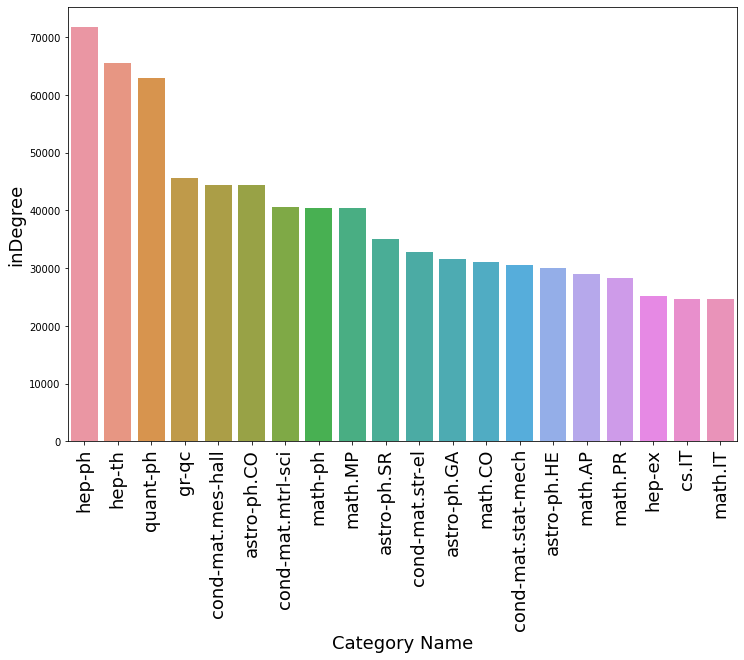

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_cat_df['c.category'], y=top_cat_df['inDegree'])
plt.xlabel('Category Name', fontsize=18)
plt.ylabel('inDegree',fontsize=18)
plt.xticks(rotation='vertical', fontsize=18)
plt.show()

# Alternative method to read graph data from Neo4j back to Python

In [ ]:
result = conn.query(query_string)

for record in result:
    print(record[0], record[1])

astro-ph 19697
hep-ph 9506
hep-th 8857
quant-ph 6279
gr-qc 5283
cond-mat.mtrl-sci 4553
cond-mat.stat-mech 4380
cond-mat.str-el 4344
math.MP 4334
math-ph 4334
cond-mat.mes-hall 3761
math.AG 2893
cond-mat.supr-con 2857
nucl-th 2769
cond-mat.other 2630
math.PR 2480
hep-ex 2461
math.CO 2397
math.DG 2237
math.AP 1996
